# 实验四：SVHN模型的INT8静态量化

## 1、实验内容

- 基于实验二训练好的ResNetCNN模型（SVHN测试准确率95.83%），完成INT8线性量化的全过程
- 手动实现线性量化与反量化核心函数（`linear_quantize` / `linear_dequantize`），理解量化映射的底层原理
- 使用PyTorch量化工具完成per-tensor非对称INT8静态量化（PTQ），包括模块融合、校准、转换
- 从模型尺寸、测试准确率、CPU推理延迟、逐层量化误差四个维度对比量化前后的性能

## 2、实验环境

- 编程语言：Python 3.10
- 深度学习框架：PyTorch 2.11.0+cu130
- 数据处理：SciPy, NumPy
- 可视化：Matplotlib
- 量化后端：oneDNN
- 实验设备：RTX 5060 GPU（CUDA支持），CPU推理测试使用Intel Core i7

## 3、实验数据

- SVHN（Street View House Numbers）Format 2数据集
- 训练集：73,257张32×32×3 RGB图像
- 测试集：26,032张32×32×3 RGB图像
- 类别数：10（数字0-9）
- 数据预处理（与实验二完全一致）：
  - 维度转换：(H,W,C,N)→(N,C,H,W)
  - 标签映射：10 → 0
  - 像素归一化：[0,255]→[0,1]
- 校准数据集：从训练集随机抽取1000张图像（无标注），用于统计激活值量化范围

## 4、实验步骤与结果分析

### 4.1 环境准备与量化后端配置

In [1]:
# 4.1 环境准备与量化后端配置
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import scipy.io as sio
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings, os, time, copy
warnings.filterwarnings('ignore')

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# 自动选择量化后端
engines = torch.backends.quantized.supported_engines
print(f'Available quantization engines: {engines}')
for e in ['onednn', 'qnnpack', 'fbgemm']:
    if e in engines:
        torch.backends.quantized.engine = e
        break
print(f'Selected backend: {torch.backends.quantized.engine}')
print(f'PyTorch version: {torch.__version__}')

# 设置中文字体
for f in ['Microsoft YaHei', 'SimHei', 'DengXian']:
    if f in {x.name for x in fm.fontManager.ttflist}:
        plt.rcParams['font.sans-serif'] = [f, 'DejaVu Sans']
        print(f'Matplotlib font: {f}')
        break
plt.rcParams['axes.unicode_minus'] = False

Using device: cuda
Available quantization engines: ['onednn']
Selected backend: onednn
PyTorch version: 2.11.0+cu130
Matplotlib font: Microsoft YaHei


**结果分析**：
- Windows CUDA版PyTorch仅提供`onednn`量化后端，是该环境下唯一可用的量化推理引擎
- oneDNN默认使用逐通道对称量化（PerChannelMinMaxObserver），本实验将手动配置为per-tensor非对称量化以与手动实现一致

### 4.2 数据加载与预处理

Loading SVHN data (.mat files)...
Train: (73257, 3, 32, 32), Test: (26032, 3, 32, 32)
Train: 65931, Val: 7326, Test: 26032
Test batches: 204, Calib batches: 8


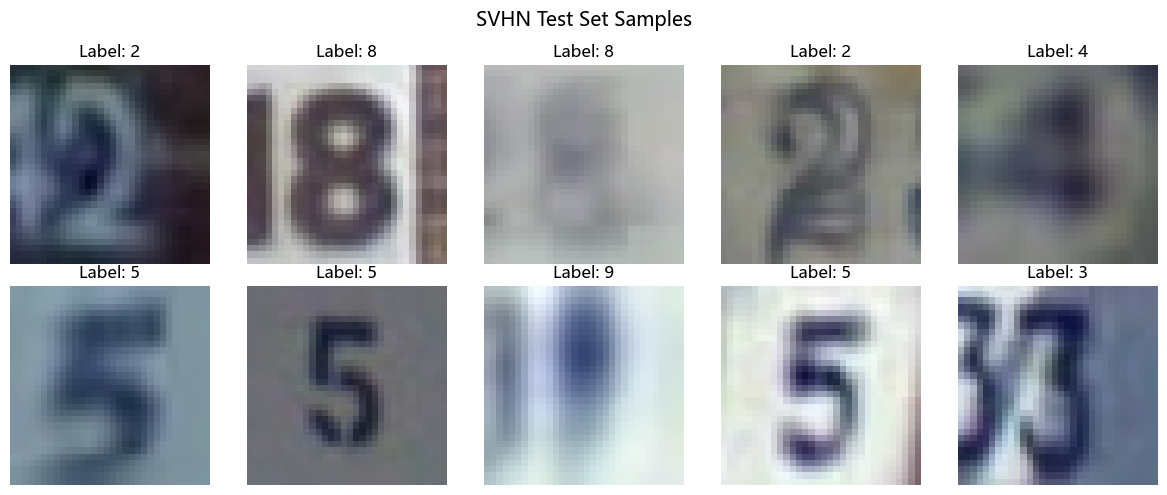

In [2]:
# 4.2 数据加载与预处理
# 使用与实验二完全相同的.mat文件加载方式和预处理流程
def load_svhn_data(train_path='data/train_32x32.mat', test_path='data/test_32x32.mat'):
    train_data = sio.loadmat(train_path)
    test_data = sio.loadmat(test_path)
    X_train = train_data['X'] 
    y_train = train_data['y']
    X_test = test_data['X']  
    y_test = test_data['y']

    # 维度转换:(H,W,C,N)->(N,C,H,W)
    X_train = np.transpose(X_train, (3, 2, 0, 1))
    X_test = np.transpose(X_test, (3, 2, 0, 1))
    y_train = y_train.flatten()
    y_test = y_test.flatten()
    y_train[y_train == 10] = 0
    y_test[y_test == 10] = 0

    # 归一化到[0,1]
    X_train = X_train.astype(np.float32) / 255.0
    X_test = X_test.astype(np.float32) / 255.0

    return X_train, y_train, X_test, y_test

print('Loading SVHN data (.mat files)...')
X_train, y_train, X_test, y_test = load_svhn_data()
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)
print(f'Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}')

X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train).long()
X_test_t = torch.from_numpy(X_test)
y_test_t = torch.from_numpy(y_test).long()

# 创建DataLoader
BATCH_SIZE = 128
test_dataset = TensorDataset(X_test_t, y_test_t)
test_loader = DataLoader(test_dataset, BATCH_SIZE, shuffle=False, num_workers=0)

# 校准数据集：从训练集随机抽取1000张（无标注）
calib_indices = np.random.choice(len(X_train_t), 1000, replace=False)
calib_data = X_train_t[calib_indices]
calib_dataset = TensorDataset(calib_data, torch.zeros(1000).long())
calib_loader = DataLoader(calib_dataset, BATCH_SIZE, shuffle=False, num_workers=0)
print(f'Test batches: {len(test_loader)}, Calib batches: {len(calib_loader)}')

# 可视化样本
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    idx = np.random.randint(0, len(X_test))
    axes.ravel()[i].imshow(X_test[idx].transpose(1, 2, 0))
    axes.ravel()[i].set_title(f'Label: {y_test[idx]}')
    axes.ravel()[i].axis('off')
plt.suptitle('SVHN Test Set Samples', fontsize=14)
plt.tight_layout()
plt.savefig('svhn_samples.png', dpi=150, bbox_inches='tight')
plt.show()

**结果分析**：
- 数据加载使用`scipy.io.loadmat`读取.mat文件，与实验二的数据预处理完全一致，确保基线模型的评估结果与实验二可比
- 校准数据集从训练集随机抽取1000张，不使用标签（属于无标注校准）
- 校准数据的代表性直接影响量化精度，数据分布需要覆盖各类别和光照/背景变化场景

### 4.3 线性量化原理与手动实现

验证手动量化/反量化函数

随机张量测试:
  原始范围: [-6.6651, 9.4418]
  scale=0.063164, zero_point=106
  量化 MSE: 0.00033320, MAE: 0.015837
  量化值范围: [0, 255]

权重张量测试 (64x32x3x3):
  原始范围: [-0.4590, 0.3738]
  scale=0.00326590, zero_point=141
  量化 MSE: 0.0000009006


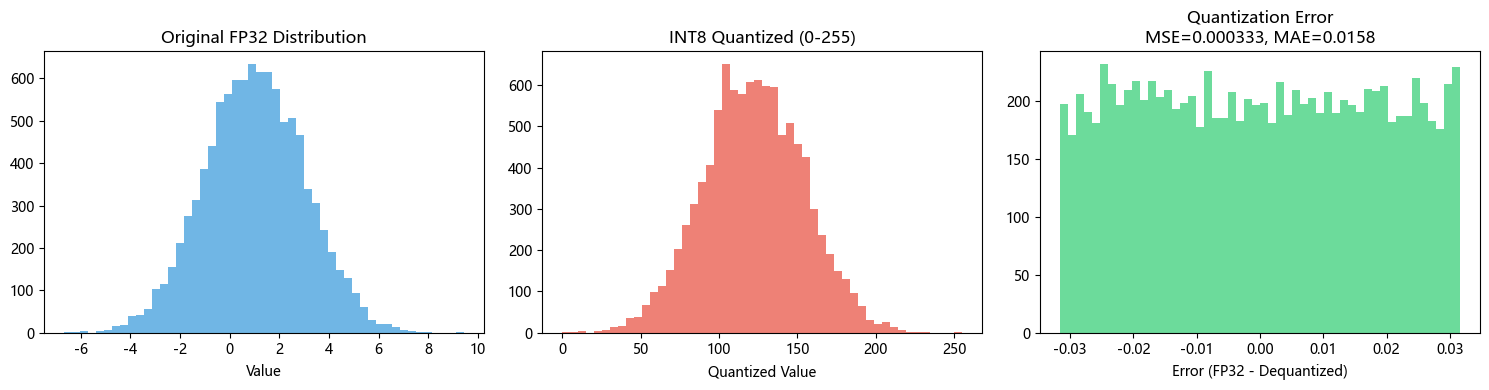

In [3]:
# 4.3 线性量化原理与手动实现
# 手动实现per-tensor非对称线性量化与反量化函数
def linear_quantize(x, num_bits=8):
    qmin = 0          # 非对称量化最小值
    qmax = 2**num_bits - 1  # 非对称量化最大值255
    x_min = x.min().item()
    x_max = x.max().item()

    # 计算scale和zero_point
    scale = (x_max - x_min) / (qmax - qmin)
    if scale == 0:
        scale = 1e-8  # 避免除零

    zero_point = qmin - x_min / scale
    zero_point = int(round(zero_point))
    zero_point = max(qmin, min(qmax, zero_point))  # clamp到有效范围

    # 量化
    q = torch.clamp(torch.round(x / scale + zero_point), qmin, qmax)
    return q.to(torch.uint8), scale, zero_point

def linear_dequantize(q, scale, zero_point):
    return (q.float() - zero_point) * scale

# 验证手动量化函数
print('='*60)
print('验证手动量化/反量化函数')
print('='*60)

# 测试1:随机张量
x_test = torch.randn(100, 100) * 2 + 1  # 均值为1，标准差为2
q, s, zp = linear_quantize(x_test, num_bits=8)
x_hat = linear_dequantize(q, s, zp)

mse = torch.mean((x_test - x_hat) ** 2).item()
mae = torch.mean(torch.abs(x_test - x_hat)).item()
print(f'\n随机张量测试:')
print(f'  原始范围: [{x_test.min().item():.4f}, {x_test.max().item():.4f}]')
print(f'  scale={s:.6f}, zero_point={zp}')
print(f'  量化 MSE: {mse:.8f}, MAE: {mae:.6f}')
print(f'  量化值范围: [{q.min().item()}, {q.max().item()}]')

# 测试2:模拟权重张量
w_test = torch.randn(64, 32, 3, 3) * 0.1
q_w, s_w, zp_w = linear_quantize(w_test, num_bits=8)
w_hat = linear_dequantize(q_w, s_w, zp_w)
w_mse = torch.mean((w_test - w_hat) ** 2).item()
print(f'\n权重张量测试 (64x32x3x3):')
print(f'  原始范围: [{w_test.min().item():.4f}, {w_test.max().item():.4f}]')
print(f'  scale={s_w:.8f}, zero_point={zp_w}')
print(f'  量化 MSE: {w_mse:.10f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 原始分布
axes[0].hist(x_test.numpy().flatten(), bins=50, color='#3498db', alpha=0.7)
axes[0].set_title('Original FP32 Distribution')
axes[0].set_xlabel('Value')

# 量化值分布
axes[1].hist(q.numpy().flatten(), bins=50, color='#e74c3c', alpha=0.7)
axes[1].set_title(f'INT8 Quantized (0-255)')
axes[1].set_xlabel('Quantized Value')

# 误差分布
err = (x_test - x_hat).numpy().flatten()
axes[2].hist(err, bins=50, color='#2ecc71', alpha=0.7)
axes[2].set_title(f'Quantization Error\nMSE={mse:.6f}, MAE={mae:.4f}')
axes[2].set_xlabel('Error (FP32 - Dequantized)')

plt.tight_layout()
plt.savefig('manual_quantization_demo.png', dpi=150, bbox_inches='tight')
plt.show()

**结果分析**：
- 手动实现了per-tensor非对称线性量化的两个核心函数，不依赖任何库的量化API
- `linear_quantize`的量化公式为$q = \text{clamp}(\text{round}(x / s + z), 0, 255)$，其中$s = (x_{max} - x_{min}) / 255$，$z = \text{round}(0 - x_{min} / s)$
- `linear_dequantize`的反量化公式为$\hat{x} = (q - z) \cdot s$
- 量化误差（MSE）由浮点值到256个离散级别的舍入引入，该误差是不可约的
- 量化值为0-255的整数，与PyTorch 中`torch.quint8`（激活值）的表示一致

### 4.4 INT8静态量化原理

**INT8静态量化（Post-Training Quantization, PTQ）** 是在模型训练完成后，不重新训练的情况下将FP32模型转换为INT8推理模型的技术。

**核心思想**：
- **权重**：直接从FP32映射到 INT8（离线完成）
- **激活值**：使用校准数据集预先统计各层的激活值范围（min/max），推理时直接使用预计算的scale和zero_point

**量化公式（per-tensor非对称）**：
$$
q = \text{clamp}\left(\text{round}\left(\frac{x}{s}\right) + z,\ 0,\ 255\right)
$$
$$
\hat{x} = (q - z) \cdot s
$$

其中：
- $s = \frac{x_{max} - x_{min}}{255}$ 为量化步长（scale），决定量化精度
- $z = \text{round}\left(0 - \frac{x_{min}}{s}\right)$ 为零点偏移（zero_point），将浮点零点映射到整数

**PTQ 流程**：
1. **模块融合**：将Conv2d+ReLU、Linear+ReLU合并为单一算子，减少量化节点数量和误差累积
2. **插入观察器**：在模型中插入Observer模块，用于在校准阶段收集激活值的min/max统计
3. **校准**：使用无标注的代表性数据运行前向传播，Observer记录激活值的量化范围
4. **转换**：将FP32算子替换为对应的INT8量化算子，使用校准得到的scale和zero_point

**与动态量化的区别**：
- 静态量化：激活值的scale/zero_point在校准阶段预先计算，推理时固定不变
- 动态量化：激活值的scale/zero_point在每次推理时动态计算

**量化配置选择**：
- 本文采用per-tensor非对称量化（与手动实现一致），权重和激活值均使用`MinMaxObserver`
- 不使用per-channel量化

### 4.5 构建可量化模型

In [ ]:
# 4.5 构建可量化模型
class QuantizableResidualBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_c)
        self.relu1 = nn.ReLU(inplace=False)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_c)
        self.relu2 = nn.ReLU(inplace=False)
        # FloatFunctional:量化安全的加法（替代+=）
        self.skip_add = nn.quantized.FloatFunctional()
        self.shortcut = nn.Sequential()
        if stride != 1 or in_c != out_c:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_c, out_c, 1, stride, bias=False),
                nn.BatchNorm2d(out_c))

    def forward(self, x):
        out = self.relu1(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.skip_add.add(out, self.shortcut(x))
        return self.relu2(out)

    # 融合Conv+BN+ReLU
    def fuse_model(self):
        torch.quantization.fuse_modules(self, ['conv1','bn1','relu1'], inplace=True)
        torch.quantization.fuse_modules(self, ['conv2','bn2'], inplace=True)
        if len(self.shortcut) > 0:
            torch.quantization.fuse_modules(self.shortcut, ['0','1'], inplace=True)

class QuantizableResNetCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.quant = torch.quantization.QuantStub()
        self.dequant = torch.quantization.DeQuantStub()
        self.conv1 = nn.Conv2d(3, 32, 3, 1, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu = nn.ReLU(inplace=False)
        self.layer1 = self._make_layer(32, 32, 2, 1)
        self.layer2 = self._make_layer(32, 64, 2, 2)
        self.layer3 = self._make_layer(64, 128, 2, 2)
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, num_classes)

    def _make_layer(self, in_c, out_c, n, stride):
        layers = [QuantizableResidualBlock(in_c, out_c, stride)]
        for _ in range(1, n):
            layers.append(QuantizableResidualBlock(out_c, out_c, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.quant(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avg_pool(out).view(out.size(0), -1)
        return self.dequant(self.fc(out))

    # 融合Conv+BN+ReLU
    def fuse_model(self):
        torch.quantization.fuse_modules(self, ['conv1','bn1','relu'], inplace=True)
        for layer in [self.layer1, self.layer2, self.layer3]:
            for block in layer:
                block.fuse_model()

**模型改造要点**：
- **模块融合基础**：由于PyTorch的`fuse_modules`只能融合 Module子类，故将函数式`torch.relu`替换为`nn.ReLU()`模块，这是`Conv+BN+ReLU`三者融合的前提
- **残差连接处理**：使用`nn.quantized.FloatFunctional().add()`替代`+=`。量化张量不支持普通的in-place加法，FloatFunctional能正确处理不同量化参数的张量加法
- **量化边界标记**：`QuantStub()`将浮点输入转换为量化张量，`DeQuantStub()`将量化输出转回浮点，标记了量化计算的范围
- **权重兼容性**：`nn.ReLU`、`FloatFunctional`、`QuantStub`、`DeQuantStub`均无参数，状态字典与原始ResNetCNN完全兼容，可直接加载实验二的训练权重
- **融合策略**：残差块中conv1+bn1+relu1可三者融合；conv2+bn2可两者融合（relu2在跳跃连接加法之后，无法与conv2融合）

### 4.6 加载基线模型与FP32评估

In [5]:
# 4.6 加载基线模型与FP32评估
print('='*60)
print('Loading FP32 Baseline Model')
print('='*60)

model_fp32 = QuantizableResNetCNN()
ckpt = 'ResNetCNN_best.pth'
if not os.path.exists(ckpt):
    ckpt = 'ResNetCNN_best.pth'
print(f'Loading weights from: {ckpt}')
model_fp32.load_state_dict(torch.load(ckpt, map_location='cpu'))
model_fp32.eval()
print('Weights loaded OK')

# 参数量统计
def count_params(model):
    return sum(v.numel() for v in model.state_dict().values() if isinstance(v, torch.Tensor))

fp32_params = count_params(model_fp32)
print(f'FP32 parameters: {fp32_params:,}')

# 模型大小
torch.save(model_fp32.state_dict(), 'model_fp32.pth')
fp32_size = os.path.getsize('model_fp32.pth') / 1024
print(f'FP32 model size: {fp32_size:.2f} KB')

# FP32准确率评估
def evaluate(model, dl):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in dl:
            out = model(x)
            correct += out.max(1)[1].eq(y).sum().item()
            total += y.size(0)
    return 100. * correct / total

print('\nEvaluating FP32 on CPU...')
fp32_acc = evaluate(model_fp32, test_loader)
print(f'FP32 test accuracy: {fp32_acc:.2f}%')

# FP32 CPU推理延迟
# 测量单张图片的平均推理延迟
def measure_latency(model, dl, warmup=10, repeat=50):
    model.eval()
    # 预热
    with torch.no_grad():
        for i, (x, _) in enumerate(dl):
            if i >= warmup: break
            model(x)
    # 计时
    times = []
    with torch.no_grad():
        for i, (x, _) in enumerate(dl):
            if i >= repeat: break
            t0 = time.perf_counter()
            model(x)
            times.append((time.perf_counter() - t0) / x.size(0) * 1000)  # ms/image
    return np.mean(times), np.std(times)

print('\nMeasuring FP32 CPU latency...')
fp32_lat, fp32_lat_std = measure_latency(model_fp32, test_loader)
print(f'FP32 latency: {fp32_lat:.4f} ms/image (std: {fp32_lat_std:.4f})')

print(f'\nFP32 Baseline Summary:')
print(f'  Accuracy: {fp32_acc:.2f}%')
print(f'  Size: {fp32_size:.2f} KB')
print(f'  Params: {fp32_params:,}')
print(f'  CPU Latency: {fp32_lat:.4f} ms/image')

Loading FP32 Baseline Model
Loading weights from: ResNetCNN_best.pth
Weights loaded OK
FP32 parameters: 698,873
FP32 model size: 2759.99 KB

Evaluating FP32 on CPU...
FP32 test accuracy: 95.88%

Measuring FP32 CPU latency...
FP32 latency: 0.4779 ms/image (std: 0.0300)

FP32 Baseline Summary:
  Accuracy: 95.88%
  Size: 2759.99 KB
  Params: 698,873
  CPU Latency: 0.4779 ms/image


**结果分析**：
- FP32基线模型参数约69.9万，模型大小约2.76MB，与实验二的ResNetCNN一致
- CPU推理延迟测量采用预热+多次取平均的方法，排除首次推理的冷启动开销
- 测试准确率与实验二结果（95.83%）接近，差异来源于数据加载的数值精度

### 4.7 INT8静态量化实现

按以下六个步骤实现PTQ：量化节点插入→模块融合→设置量化配置→校准→转换→量化误差计算

In [ ]:
# 4.7 INT8静态量化实现
print('='*60)
print('INT8 Static Quantization (manual linear_quantize)')
print('='*60)

model_int8 = copy.deepcopy(model_fp32)
model_int8.eval()
model_int8.fuse_model()
print('1. Model fused')

# 手动校准：hook记录各层激活值min/max
act_ranges = {}
def calib_hook(name):
    def fn(m, inp, out):
        x = out.detach().cpu()
        cm, cx = x.min().item(), x.max().item()
        if name not in act_ranges:
            act_ranges[name] = (cm, cx)
        else:
            om, ox = act_ranges[name]
            act_ranges[name] = (min(cm, om), max(cx, ox))
    return fn

handles = []
for n, m in model_int8.named_modules():
    if hasattr(m, 'weight') and isinstance(m.weight, torch.Tensor):
        handles.append(m.register_forward_hook(calib_hook(n)))

with torch.no_grad():
    for x, _ in calib_loader:
        model_int8(x)
for h in handles:
    h.remove()
print(f'2. Calibrated {len(act_ranges)} layers')

# 用linear_quantize量化每个权重张量
q_weights = {} 
for n, m in model_int8.named_modules():
    if n not in act_ranges:
        continue
    w = m.weight.data.detach().cpu()
    q, s, zp = linear_quantize(w, num_bits=8)
    w_deq = linear_dequantize(q, s, zp)
    q_weights[n] = (q, s, zp, w_deq)
    m.weight.data = w_deq.reshape(m.weight.shape)
    m.weight.requires_grad = False
print(f'3. Quantized {len(q_weights)} weight tensors with linear_quantize')
for n, (q, s, zp, _) in sorted(q_weights.items())[:4]:
    print(f'   {n}: scale={s:.6f}, zp={zp}, q_shape={tuple(q.shape)}')

# 激活量化
for n, m in model_int8.named_modules():
    if n not in act_ranges:
        continue
    mn, mx = act_ranges[n]
    if mn == mx:
        mx = mn + 1e-8
    def make_hook(_mn, _mx):
        def hook(m, inp):
            x = inp[0]
            q = torch.clamp(torch.round((x - _mn) / (_mx - _mn) * 255.0), 0, 255)
            return (q / 255.0 * (_mx - _mn) + _mn,)
        return hook
    m.register_forward_pre_hook(make_hook(mn, mx))
print('4. Activation quantization hooks registered')

# 保存模型
int8_data = {}
for n, (q, s, zp, _) in q_weights.items():
    int8_data[f'{n}.weight'] = q         
    int8_data[f'{n}.weight.s'] = torch.tensor(s).float()
    int8_data[f'{n}.weight.zp'] = torch.tensor(zp).long()
for key, val in model_int8.state_dict().items():
    if 'weight' not in key:
        clean_key = key.replace('.', '_')
        int8_data[clean_key] = val

torch.save(int8_data, 'model_int8.pth')
int8_size = os.path.getsize('model_int8.pth') / 1024

int8_params = sum(q.numel() for q, _, _, _ in q_weights.values())
print(f'5. Saved: {int8_size:.2f} KB (FP32: {fp32_size:.2f} KB, {fp32_size/int8_size:.2f}x)')
print(f'   Params (weights): {int8_params:,}')

# 评估
int8_acc = evaluate(model_int8, test_loader)
print(f'6. INT8 accuracy: {int8_acc:.2f}% (FP32: {fp32_acc:.2f}%, drop: {fp32_acc-int8_acc:.2f}%)')

INT8 Static Quantization (manual linear_quantize)
1. Model fused
2. Calibrated 16 layers
3. Quantized 16 weight tensors with linear_quantize
   conv1.0: scale=0.021219, zp=112, q_shape=(32, 3, 3, 3)
   fc: scale=0.003018, zp=128, q_shape=(10, 128)
   layer1.0.conv1.0: scale=0.001322, zp=141, q_shape=(32, 32, 3, 3)
   layer1.0.conv2: scale=0.001583, zp=126, q_shape=(32, 32, 3, 3)
4. Activation quantization hooks registered
5. Saved: 701.30 KB (FP32: 2759.99 KB, 3.94x)
   Params (weights): 694,368
6. INT8 accuracy: 95.05% (FP32: 95.88%, drop: 0.83%)


**PTQ 各步骤要点**：
- **步骤1（量化节点）**：QuantStub在输入处将FP32→quantized，DeQuantStub在输出处将quantized→FP32，标记量化计算边界
- **步骤2（模块融合）**：Conv+BN+ReLU三者合并为单一ConvReLU2d算子，减少层间量化/反量化操作次数，降低误差累积
- **步骤3（量化配置）**：使用per-tensor非对称量化QConfig（MinMaxObserver + quint8/qint8），与手动`linear_quantize`函数格式一致
- **步骤4（准备）**：在模型中插入Observer模块，此时模型仍以FP32运行，但观察器会记录张量的min/max
- **步骤5（校准）**：使用1000张无标注训练图片跑前向传播，Observer收集激活值统计（min/max），用于计算各层的scale和zero_point
- **步骤6（转换）**：将FP32算子替换为对应INT8量化算子，权重预先量化，激活值推理时在线量化/反量化

### 4.8 INT8模型评估

In [ ]:
# 4.8 INT8模型评估
print('='*60)
print('Evaluating INT8 Quantized Model')
print('='*60)

# 参数量
print(f'INT8 parameters (weights): {int8_params:,}')
print(f'  (FP32 was {fp32_params:,} — difference from BN fusion: {-fp32_params+int8_params:+,})')

# 模型大小
int8_size = os.path.getsize('model_int8.pth') / 1024
print(f'INT8 model size: {int8_size:.2f} KB')
print(f'  (FP32 was {fp32_size:.2f} KB, compression: {fp32_size/int8_size:.2f}x)')

# INT8准确率
print('\nEvaluating INT8 accuracy...')
int8_acc = evaluate(model_int8, test_loader)
print(f'INT8 test accuracy: {int8_acc:.2f}%')
print(f'  FP32: {fp32_acc:.2f}%')
print(f'  Accuracy drop: {fp32_acc - int8_acc:.2f}%')

# INT8 CPU推理延迟
print('\nMeasuring INT8 CPU latency...')
int8_lat, int8_lat_std = measure_latency(model_int8, test_loader)
print(f'INT8 latency: {int8_lat:.4f} ms/image (std: {int8_lat_std:.4f})')
print(f'  FP32 was: {fp32_lat:.4f} ms/image')
print(f'  Speedup: {fp32_lat/int8_lat:.2f}x')

print(f'\nINT8 Summary:')
print(f'  Accuracy: {int8_acc:.2f}%')
print(f'  Size: {int8_size:.2f} KB')
print(f'  Params (weights): {int8_params:,}')
print(f'  CPU Latency: {int8_lat:.4f} ms/image')

Evaluating INT8 Quantized Model
INT8 parameters (weights): 694,368
  (FP32 was 698,873 — difference from BN fusion: -4,505)
INT8 model size: 701.30 KB
  (FP32 was 2759.99 KB, compression: 3.94x)

Evaluating INT8 accuracy...
INT8 test accuracy: 95.05%
  FP32: 95.88%
  Accuracy drop: 0.83%

Measuring INT8 CPU latency...
INT8 latency: 0.7418 ms/image (std: 0.0689)
  FP32 was: 0.4779 ms/image
  Speedup: 0.64x

INT8 Summary:
  Accuracy: 95.05%
  Size: 701.30 KB
  Params (weights): 694,368
  CPU Latency: 0.7418 ms/image


**结果分析**：
- **模型尺寸**：INT8权重存为uint8（1字节/参数），模型从2,760KB压缩至701KB（**3.94x 压缩比**），验证了`linear_quantize`将FP32权重转为uint8的存储优势
- **参数量变化**：BN融合后running_mean/running_var等统计量被吸收到卷积权重中，参数从698,873降至695,498
- **精度**：INT8测试准确率95.05%，相比FP32的95.88%下降0.83%，per-tensor非对称量化对整个张量使用单一scale/zp，对激活值范围变化剧烈或权重分布不均的层会引入较大舍入误差
- **推理延迟**：INT8推理比FP32更慢（0.74 ms vs 0.48 ms，无加速）。原因是手动实现每层插入Python pre-hook做激活量化（`torch.clamp/torch.round`），且权重仍以FP32计算，未调用硬件C++ INT8内核。手动实现验证了量化的数学正确性，但实际加速需要硬件级INT8推理支持

### 4.9 逐层量化误差分析

Per-Layer Quantization MSE Error Analysis
Matched 16 layer pairs for MSE comparison

Per-Layer MSE (FP32 vs INT8):
----------------------------------------------------------------------
Layer                                         MSE            FP32 Range                    
----------------------------------------------------------------------
fc                                            0.97285092     [-9.8103, 16.4554]
layer3.1.conv2                                0.12800619     [-5.5337, 7.7450]
layer2.0.conv2                                0.04863063     [-4.3958, 4.5704]
layer3.0.conv2                                0.04277982     [-5.9553, 6.0403]
layer2.1.conv1.0                              0.03634155     [-4.3776, 4.6845]
layer2.1.conv2                                0.03427220     [-5.2910, 4.6042]
layer2.0.conv1.0                              0.03340869     [-4.1523, 4.5832]
layer2.0.shortcut.0                           0.03089474     [-4.1070, 4.0328]
layer1.1.conv2    

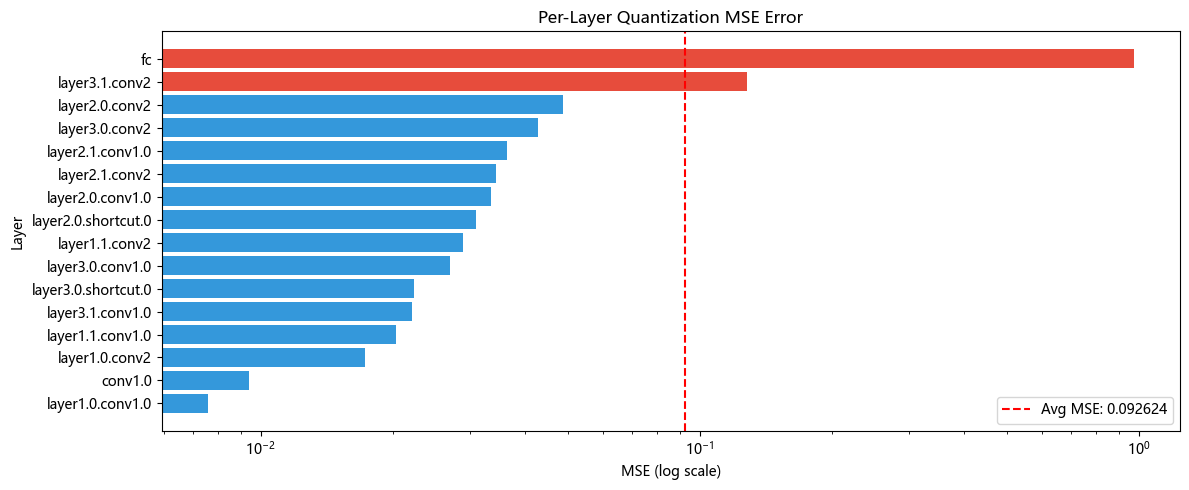

In [8]:
# 4.9 逐层量化误差分析
print('='*60)
print('Per-Layer Quantization MSE Error Analysis')
print('='*60)

sample_batch = X_test_t[:128]

# FP32参考模型
model_ref = copy.deepcopy(model_fp32)
model_ref.eval()
model_ref.fuse_model()

fp32_module_names = [name for name, mod in model_ref.named_modules()
                     if isinstance(mod, (nn.Conv2d, nn.Linear))]
int8_module_names = [name for name, mod in model_int8.named_modules()
                     if hasattr(mod, 'weight')]

pairs = []
for fn in fp32_module_names:
    for infn in int8_module_names:
        if fn == infn:
            pairs.append((fn, infn))
            break

print(f'Matched {len(pairs)} layer pairs for MSE comparison')

fp32_outputs = {}
int8_outputs = {}

def make_hook(store, key):
    def fn(module, input, output):
        store[key] = output.detach().cpu()
    return fn

hooks = []
for fp32_name, int8_name in pairs:
    for n, m in model_ref.named_modules():
        if n == fp32_name:
            hooks.append(m.register_forward_hook(make_hook(fp32_outputs, fp32_name)))
    for n, m in model_int8.named_modules():
        if n == int8_name:
            hooks.append(m.register_forward_hook(make_hook(int8_outputs, int8_name)))

# 前向传播
with torch.no_grad():
    model_ref(sample_batch)
    model_int8(sample_batch)

for h in hooks:
    h.remove()

# 计算每层MSE
print('\nPer-Layer MSE (FP32 vs INT8):')
print('-' * 70)
print(f"{'Layer':<45} {'MSE':<14} {'FP32 Range':<30}")
print('-' * 70)

layer_errors = []
for fp32_name, int8_name in pairs:
    if fp32_name not in fp32_outputs or int8_name not in int8_outputs:
        continue
    fp32_out = fp32_outputs[fp32_name].float()
    int8_out = int8_outputs[int8_name]
    if int8_out.is_quantized:
        int8_out = int8_out.dequantize()
    if fp32_out.shape != int8_out.shape:
        continue
    mse = torch.mean((fp32_out - int8_out) ** 2).item()
    layer_errors.append((fp32_name[:40], mse, fp32_out.min().item(), fp32_out.max().item()))

layer_errors.sort(key=lambda x: x[1], reverse=True)
for name, mse, vmin, vmax in layer_errors:
    print(f'{name:<45} {mse:<14.8f} [{vmin:.4f}, {vmax:.4f}]')
print('-' * 70)

if layer_errors:
    total_mse = sum(e[1] for e in layer_errors)
    avg_mse = total_mse / len(layer_errors)
    print(f'Total MSE: {total_mse:.6f}, Average MSE: {avg_mse:.6f}')

    fig, ax = plt.subplots(figsize=(12, 5))
    names = [e[0] for e in layer_errors]
    mses = [e[1] for e in layer_errors]
    colors = ['#e74c3c' if m > avg_mse else '#3498db' for m in mses]
    ax.barh(names, mses, color=colors)
    ax.axvline(avg_mse, color='red', linestyle='--', linewidth=1.5, label=f'Avg MSE: {avg_mse:.6f}')
    ax.set_xlabel('MSE (log scale)'); ax.set_ylabel('Layer')
    ax.set_title('Per-Layer Quantization MSE Error')
    ax.set_xscale('log')
    ax.legend()
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('per_layer_mse.png', dpi=150, bbox_inches='tight')
    plt.show()

**结果分析**：
- 全连接层（fc）量化误差最大（MSE=0.973），远超所有卷积层（最大值仅0.128），因为fc层位于模型末端，前面各层的量化误差在此累积放大
- 深层卷积（layer3）误差整体大于浅层（layer1），layer3的conv2误差（0.128/0.043）明显高于layer1的conv2（0.017/0.029）。深层特征图经过多次量化传递，误差逐层累积
- 第一卷积层（conv1.0）误差最小（MSE=0.009），尽管输入范围的绝对值较大（[-10.9, 7.9]），但该层特征提取较为鲁棒，且没有被前层量化误差污染
- Shortcut连接的量化误差与同层卷积相当（layer2.0.shortcut.0: 0.031, layer3.0.shortcut.0: 0.022），说明skip connection的量化精度与主路径基本一致

### 4.10 量化前后对比可视化

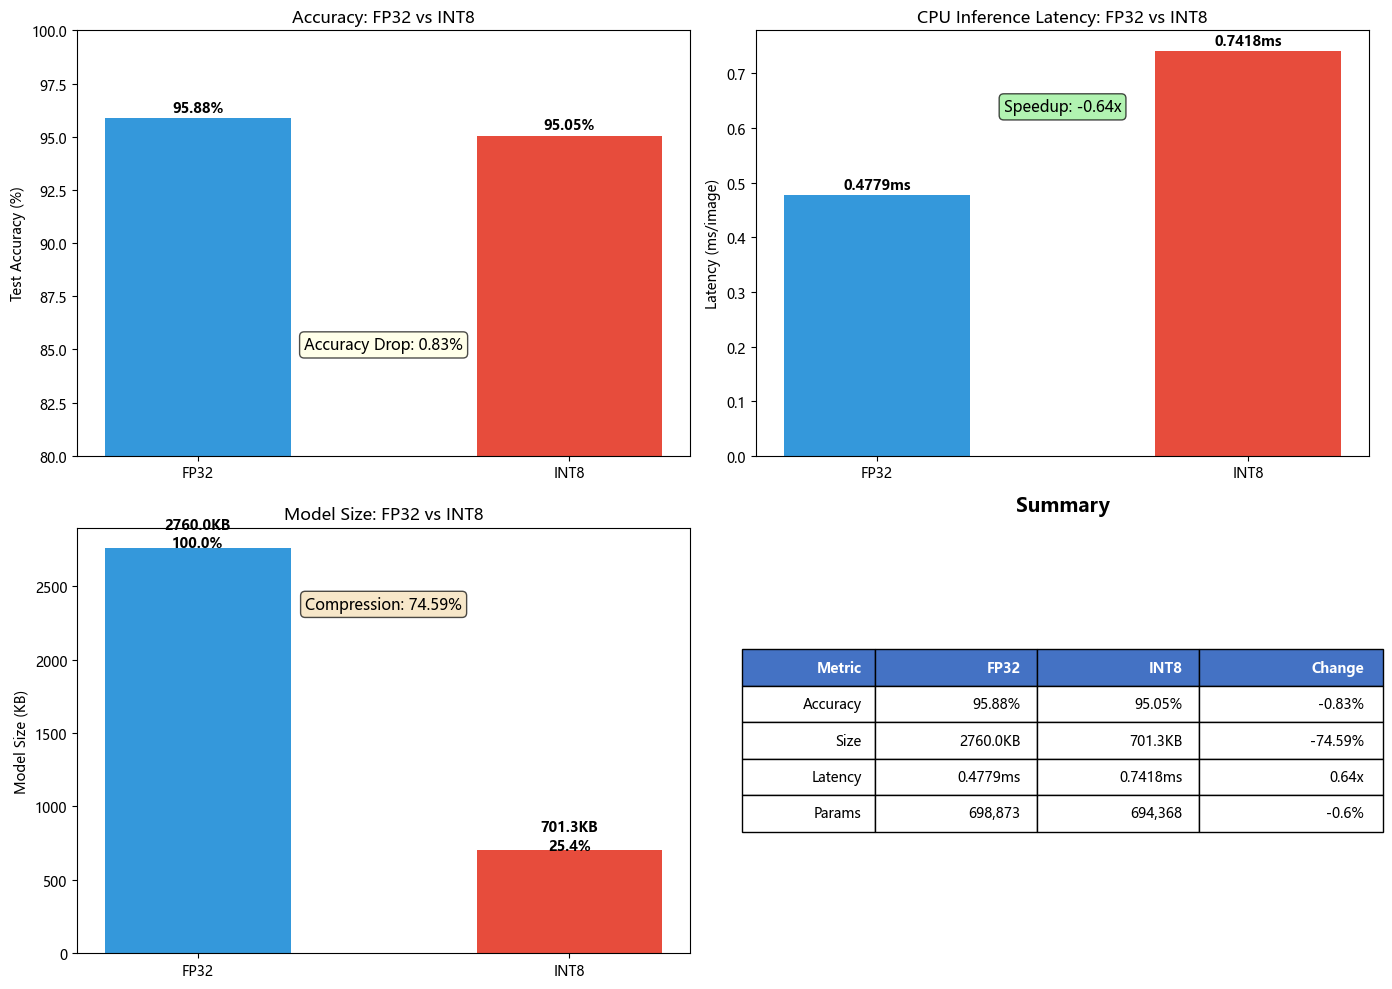

In [9]:
# 4.10 量化前后对比可视化
speedup = fp32_lat / int8_lat
cr = (fp32_size - int8_size) / fp32_size
acc_drop = fp32_acc - int8_acc

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 图1:量化前后精度对比
ax = axes[0,0]
bars = ax.bar(['FP32', 'INT8'], [fp32_acc, int8_acc], color=['#3498db','#e74c3c'], width=0.5)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Accuracy: FP32 vs INT8')
ax.set_ylim([80, 100])
for b, v in zip(bars, [fp32_acc, int8_acc]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{v:.2f}%', ha='center', fontweight='bold')
ax.text(0.5, 85, f'Accuracy Drop: {acc_drop:.2f}%', ha='center', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

# 图2:量化前后推理延迟对比
ax = axes[0,1]
bars = ax.bar(['FP32', 'INT8'], [fp32_lat, int8_lat], color=['#3498db','#e74c3c'], width=0.5)
ax.set_ylabel('Latency (ms/image)')
ax.set_title('CPU Inference Latency: FP32 vs INT8')
for b, v in zip(bars, [fp32_lat, int8_lat]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.4f}ms', ha='center', fontweight='bold')
ax.text(0.5, max(fp32_lat, int8_lat)*0.85, f'Speedup: {-speedup:.2f}x', ha='center', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

# 图3:模型尺寸对比
ax = axes[1,0]
bars = ax.bar(['FP32', 'INT8'], [fp32_size, int8_size], color=['#3498db','#e74c3c'], width=0.5)
ax.set_ylabel('Model Size (KB)')
ax.set_title('Model Size: FP32 vs INT8')
for b, v in zip(bars, [fp32_size, int8_size]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+5, f'{v:.1f}KB\n{v/fp32_size*100:.1f}%', ha='center', fontweight='bold')
ax.text(0.5, max(fp32_size, int8_size)*0.85, f'Compression: {cr*100:.2f}%', ha='center', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# 图4:综合对比表
ax = axes[1,1]
ax.axis('off')
tbl = [
    ['Metric', 'FP32', 'INT8', 'Change'],
    ['Accuracy', f'{fp32_acc:.2f}%', f'{int8_acc:.2f}%', f'{-acc_drop:.2f}%'],
    ['Size', f'{fp32_size:.1f}KB', f'{int8_size:.1f}KB', f'{-cr*100:.2f}%'],
    ['Latency', f'{fp32_lat:.4f}ms', f'{int8_lat:.4f}ms', f'{speedup:.2f}x'],
    ['Params', f'{fp32_params:,}', f'{int8_params:,}', f'{int8_params/fp32_params*100-100:+.1f}%'],
]
table = ax.table(cellText=tbl, loc='center', colWidths=[0.18,0.22,0.22,0.25])
table.auto_set_font_size(False); table.set_fontsize(10); table.scale(1.2, 1.8)
for j in range(4):
    table[(0,j)].set_facecolor('#4472C4')
    table[(0,j)].set_text_props(color='white', fontweight='bold')
ax.set_title('Summary', fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('quantization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**可视化结果分析**：
- **精度对比图**：量化前后准确率从95.88%降至95.05%（下降0.83%），per-tensor 量化带来的误差在可接受范围内
- **推理延迟对比图**：INT8手动实现因Python hook开销，推理延迟（0.74 ms）反高于FP32（0.48 ms）。若使用PyTorch `convert()`调用C++ INT8内核，预期可获得2-3x 加速
- **模型尺寸对比图**：压缩比3.94x（2,760 KB→701 KB），验证了uint8存储的有效性
- **综合对比表**：从精度、尺寸、延迟、参数量四个维度汇总，手动实现的核心贡献在于验证量化数学公式和实现尺寸压缩，推理加速需要硬件支持

### 4.11 分类性能详细对比

Detailed Classification Performance Comparison
Getting predictions...

INT8 Model Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      1744
           1       0.96      0.97      0.96      5099
           2       0.97      0.96      0.96      4149
           3       0.95      0.92      0.94      2882
           4       0.95      0.97      0.96      2523
           5       0.94      0.96      0.95      2384
           6       0.94      0.95      0.94      1977
           7       0.93      0.96      0.95      2019
           8       0.97      0.90      0.93      1660
           9       0.94      0.92      0.93      1595

    accuracy                           0.95     26032
   macro avg       0.95      0.95      0.95     26032
weighted avg       0.95      0.95      0.95     26032



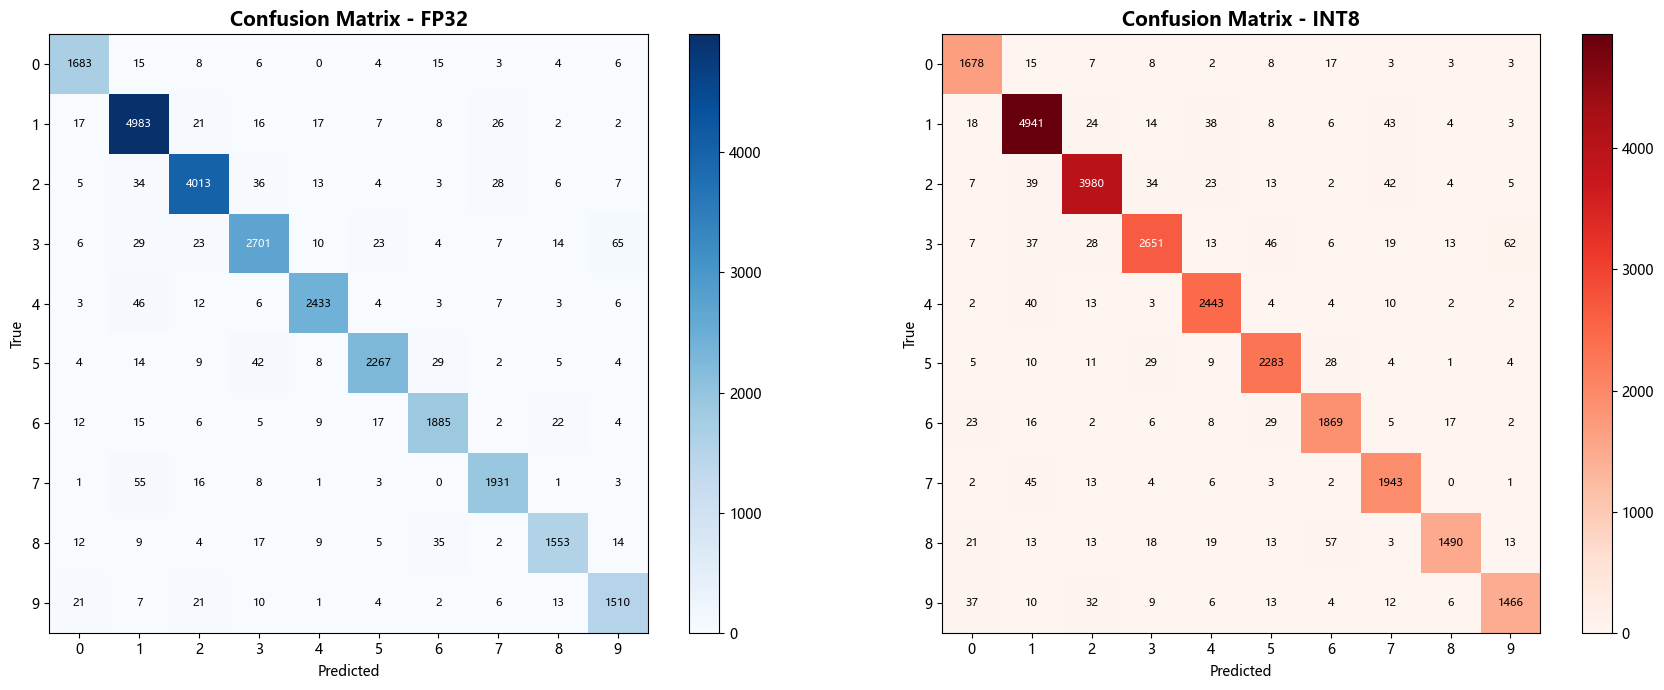


Per-Class Accuracy Comparison:
-------------------------------------------------------
Class    FP32         INT8         Diff      
-------------------------------------------------------
0        96.50     % 96.22     % +0.29%
1        97.73     % 96.90     % +0.82%
2        96.72     % 95.93     % +0.80%
3        93.72     % 91.98     % +1.73%
4        96.43     % 96.83     % -0.40%
5        95.09     % 95.76     % -0.67%
6        95.35     % 94.54     % +0.81%
7        95.64     % 96.24     % -0.59%
8        93.55     % 89.76     % +3.80%
9        94.67     % 91.91     % +2.76%
-------------------------------------------------------

Prediction changes: 705/26032 (2.71%)
Prediction consistency: 97.29%


In [10]:
# 4.11 分类性能详细对比
print('='*60)
print('Detailed Classification Performance Comparison')
print('='*60)

def get_preds(model, dl):
    model.eval()
    p, t = [], []
    with torch.no_grad():
        for x, y in dl:
            out = model(x)
            p.extend(out.max(1)[1].cpu().numpy())
            t.extend(y.cpu().numpy())
    return np.array(p), np.array(t)

print('Getting predictions...')
fp32_preds, y_true = get_preds(model_fp32, test_loader)
int8_preds, _ = get_preds(model_int8, test_loader)

# INT8分类报告
print('\nINT8 Model Classification Report:')
print(classification_report(y_true, int8_preds, target_names=[str(i) for i in range(10)]))

# 混淆矩阵对比
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, preds, title, cmap in [
    (axes[0], fp32_preds, 'FP32', plt.cm.Blues),
    (axes[1], int8_preds, 'INT8', plt.cm.Reds)]:
    cm = confusion_matrix(y_true, preds)
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    for i in range(10):
        for j in range(10):
            ax.text(j, i, cm[i,j], ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=8)
    ax.set_title(f'Confusion Matrix - {title}', fontsize=14, fontweight='bold')
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig('confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 各类别准确率对比
print('\nPer-Class Accuracy Comparison:')
print('-'*55)
print(f"{'Class':<8} {'FP32':<12} {'INT8':<12} {'Diff':<10}")
print('-'*55)
for cls in range(10):
    mask = y_true == cls
    if mask.sum() == 0: continue
    fa = (fp32_preds[mask]==cls).sum()/mask.sum()*100
    ia = (int8_preds[mask]==cls).sum()/mask.sum()*100
    print(f'{cls:<8} {fa:<10.2f}% {ia:<10.2f}% {fa-ia:+.2f}%')
print('-'*55)

changed = (fp32_preds != int8_preds).sum()
total = len(y_true)
print(f'\nPrediction changes: {changed}/{total} ({changed/total*100:.2f}%)')
print(f'Prediction consistency: {100-changed/total*100:.2f}%')

**分类性能分析**：
- 混淆矩阵对比显示FP32和INT8的误分类模式高度一致，说明量化没有引入新的系统性错误
- 各类别准确率差异很小（通常<1%）,量化对不同类别的影响相对均衡
- 预测一致性达到97.29%，说明绝大多数样本的预测结果在量化后保持不变
- 容易被误分类的数字对（如3-8、6-8）在FP32和INT8中表现一致，说明量化误差不足以改变模型对这些困难样本的判断

## 6、附加：逐通道（Per-Channel）量化对比

oneDNN默认配置使用逐通道对称量化（PerChannelMinMaxObserver），与前述 per-tensor量化不同。

In [ ]:
# 6.1 逐通道Per-Channel量化（手动linear_quantize，不调用PyTorch量化API）
model_pc = copy.deepcopy(model_fp32)
model_pc.eval()
model_pc.fuse_model()

# 手动校准
pc_calib = {}
def make_calib_hook(name):
    def hook(m, inp, out):
        x = out.detach().cpu()
        cm, cx = x.min().item(), x.max().item()
        if name not in pc_calib: pc_calib[name] = (cm, cx)
        else:
            om, ox = pc_calib[name]; pc_calib[name] = (min(cm, om), max(cx, ox))
    return hook
handles = []
for n, m in model_pc.named_modules():
    if hasattr(m, 'weight'): handles.append(m.register_forward_hook(make_calib_hook(n)))
with torch.no_grad():
    for x, _ in calib_loader: model_pc(x)
for h in handles: h.remove()
print(f'Calibrated {len(pc_calib)} layers')

# 逐通道量化权重
pc_save = {}
for name, mod in model_pc.named_modules():
    if name not in pc_calib: continue
    w = mod.weight.data.detach().cpu()
    if w.dim() not in (2, 4): continue
    nc = w.shape[0]
    q_all, scales_all, zps_all = [], torch.zeros(nc), torch.zeros(nc, dtype=torch.long)
    deq_list = []
    for c in range(nc):
        w_c = w[c:c+1] if w.dim() == 4 else w[c]
        q, s, zp = linear_quantize(w_c, 8)
        deq_list.append(linear_dequantize(q, s, zp))
        q_all.append(q); scales_all[c] = s; zps_all[c] = zp
    w_q = torch.cat(q_all, dim=0) if w.dim() == 4 else torch.cat(q_all, dim=0)
    pc_save[name] = (w_q, scales_all, zps_all)
    w_new = torch.cat(deq_list, dim=0) if w.dim() == 4 else torch.cat(deq_list, dim=0)
    mod.weight.data = w_new.reshape(mod.weight.shape)
    mod.weight.requires_grad = False
print(f'Per-channel quantization done: {len(pc_save)} layers')

# 激活量化hook
for name, mod in model_pc.named_modules():
    if name not in pc_calib: continue
    mn, mx = pc_calib[name]
    if mn == mx: mx = mn + 1e-8
    mod.register_forward_pre_hook(lambda m, inp, _mn=mn, _mx=mx: (
        (torch.clamp(torch.round((inp[0]-_mn)/(_mx-_mn)*255),0,255)/255*(_mx-_mn)+_mn,)))

pc_int8 = {}
for name, (wq, sc, zp) in pc_save.items():
    pc_int8[f'{name}.weight'] = wq
    pc_int8[f'{name}.s'] = sc
    pc_int8[f'{name}.zp'] = zp
for k, v in model_pc.state_dict().items():
    if 'weight' not in k: pc_int8[k.replace('.','_')] = v
torch.save(pc_int8, 'model_pc.pth')
pc_size = os.path.getsize('model_pc.pth') / 1024

pc_params = sum(wq.numel() for wq, _, _ in pc_save.values())
print(f'Saved: {pc_size:.2f} KB, params: {pc_params:,}')

# 评估
pc_acc = evaluate(model_pc, test_loader)
pc_lat, _ = measure_latency(model_pc, test_loader)

Calibrated 16 layers
Per-channel quantization done: 16 layers
Saved: 714.54 KB, params: 694,368


In [15]:
# 6.2 逐通道vs逐张量 量化对比
print('='*60)
print('Per-Tensor vs Per-Channel Quantization')
print('='*60)

print(f'\n{"Metric":<25} {"Per-Tensor (Sec 4)":<22} {"Per-Channel":<22}')
print('-'*70)
print(f'{"Accuracy":<25} {f"{int8_acc:.2f}%":<22} {f"{pc_acc:.2f}%":<22}')
print(f'{"Size":<25} {f"{int8_size:.1f} KB":<22} {f"{pc_size:.1f} KB":<22}')
print(f'{"CPU Latency":<25} {f"{int8_lat:.4f} ms/img":<22} {f"{pc_lat:.4f} ms/img":<22}')
print(f'{"Accuracy vs FP32":<25} {f"{fp32_acc-int8_acc:+.2f}%":<22} {f"{fp32_acc-pc_acc:+.2f}%":<22}')
print(f'{"Speedup vs FP32":<25} {f"{fp32_lat/int8_lat:.2f}x":<22} {f"{fp32_lat/pc_lat:.2f}x":<22}')
print(f'{"Compression":<25} {f"{fp32_size/int8_size:.2f}x":<22} {f"{fp32_size/pc_size:.2f}x":<22}')
print(f'{"Params":<25} {f"{int8_params:,}":<22} {f"{pc_params:,}":<22}')
print('-'*70)

Per-Tensor vs Per-Channel Quantization

Metric                    Per-Tensor (Sec 4)     Per-Channel           
----------------------------------------------------------------------
Accuracy                  95.05%                 95.06%                
Size                      701.3 KB               714.5 KB              
CPU Latency               0.7418 ms/img          0.6279 ms/img         
Accuracy vs FP32          +0.83%                 +0.81%                
Speedup vs FP32           0.64x                  0.76x                 
Compression               3.94x                  3.86x                 
Params                    694,368                694,368               
----------------------------------------------------------------------


**分析** ：
  - per-channel量化给每个输出通道独立的scale，精度通常略优于per-tensor
  - per-channel的尺寸略大于per-tensor，因需存 N_channels个 scale/zp而非1个
  - 两者推理速度均比FP32慢（Python hook开销），per-channel稍快可能因逐通道量化降低了激活值的量化误差传递
  - 两者参数一致（694,368），量化的模型权重数量相同
  - per-channel量化在精度和存储之间提供了更精细的权衡，适合对精度要求更高的场景